# BAN 612 — Data Science & AI Job Market Analysis
## Notebook 2: Analysis & Visualization

**Team Members:** [Member 1], [Member 2], [Member 3], Miguel Davila

**Objective:** Analyze 1,653 cleaned job listings across Data Science and AI roles to answer five research questions about job market trends, geographic distribution, experience requirements, and role evolution.

---

### AI Usage Disclosure
- **Claude (Anthropic)** was used to help structure the analysis framework, suggest visualization types, and assist with plotting code.
- All interpretations, conclusions, and managerial recommendations are the team's own.

---

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palettes
DOMAIN_COLORS = {'Data Science': '#2196F3', 'AI': '#FF5722'}
CATEGORY_PALETTE = sns.color_palette('husl', 12)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load cleaned dataset from Notebook 1
df = pd.read_csv('job_listings_cleaned.csv')

print(f"Dataset: {len(df)} job listings")
print(f"Domains: {df['domain'].value_counts().to_dict()}")
print(f"Categories: {df['job_category'].nunique()}")
print(f"States: {df['state'].nunique()}")
print(f"\nColumn types: {df.dtypes.value_counts().to_dict()}")

Dataset: 1598 job listings
Domains: {'Data Science': 1124, 'AI': 474}
Categories: 12
States: 20

Column types: {dtype('O'): 12, dtype('float64'): 3, dtype('bool'): 3, dtype('int64'): 2}


## 2. Dataset Overview

Before diving into research questions, we present a high-level summary of the dataset.

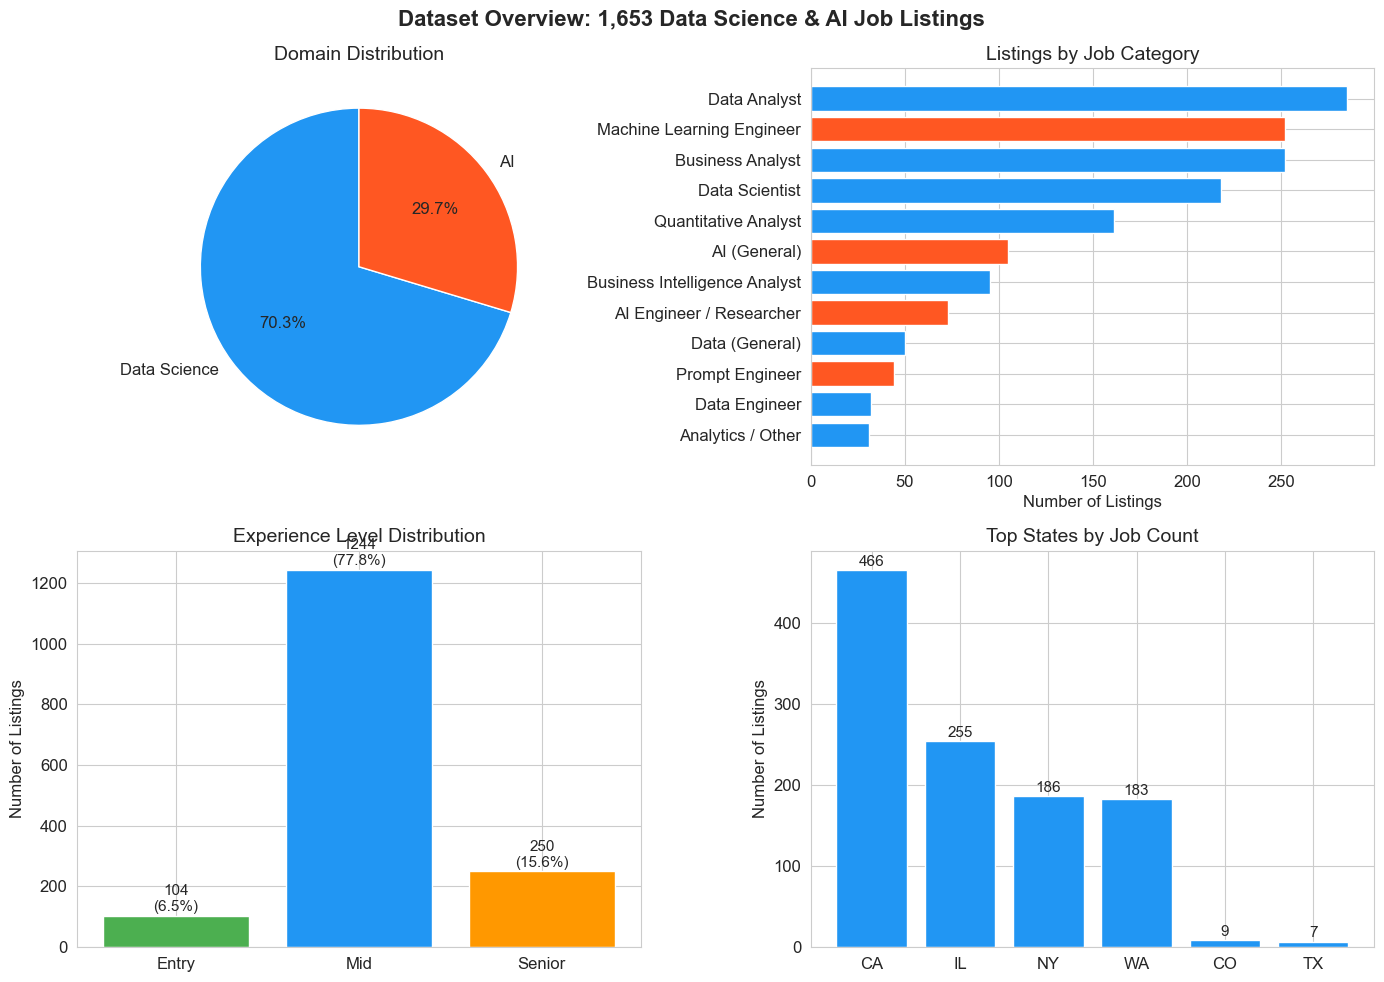

Saved: fig_overview.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Overview: 1,653 Data Science & AI Job Listings', fontsize=16, fontweight='bold')

# 1. Domain split — Pie Chart (Lecture Part 1, Example 1)
domain_counts = df['domain'].value_counts()
colors = [DOMAIN_COLORS[d] for d in domain_counts.index]
axes[0, 0].pie(domain_counts, labels=domain_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Domain Distribution')

# 2. Top job categories — Horizontal Bar Chart (Lecture Part 2, Example 5)
cat_counts = df['job_category'].value_counts()
cat_colors = [DOMAIN_COLORS.get(df[df['job_category']==c]['domain'].mode()[0], '#999')
              for c in cat_counts.index]
axes[0, 1].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color=cat_colors[::-1], edgecolor='white')
axes[0, 1].set_title('Listings by Job Category')
axes[0, 1].set_xlabel('Number of Listings')

# 3. Experience level — Bar Chart
exp_order = ['Entry', 'Mid', 'Senior']
exp_counts = df['experience_level'].value_counts().reindex(exp_order)
axes[1, 0].bar(exp_counts.index, exp_counts.values, color=['#4CAF50', '#2196F3', '#FF9800'],
               edgecolor='white')
axes[1, 0].set_title('Experience Level Distribution')
axes[1, 0].set_ylabel('Number of Listings')
for i, v in enumerate(exp_counts.values):
    axes[1, 0].text(i, v + 15, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)

# 4. Top states — Bar Chart
state_counts = df['state'].value_counts().head(6)
axes[1, 1].bar(state_counts.index, state_counts.values, color='#2196F3', edgecolor='white')
axes[1, 1].set_title('Top States by Job Count')
axes[1, 1].set_ylabel('Number of Listings')
for i, v in enumerate(state_counts.values):
    axes[1, 1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_overview.png")

---
## 3. Research Question 1: DS vs AI Demand by City

**Question:** What is the ratio of Data Science to AI roles across major metros? Are certain cities more AI-heavy?

**Why it matters:** Companies and job seekers benefit from understanding which markets are leading in AI adoption vs. maintaining traditional analytics demand.

In [4]:
# Filter to top states with meaningful sample sizes
top_states = df['state'].value_counts().head(4).index.tolist()  # CA, IL, NY, WA
df_states = df[df['state'].isin(top_states)].copy()

# Crosstab: state x domain (Lecture Part 2 — pd.crosstab with tips data)
ct = pd.crosstab(df_states['state'], df_states['domain'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Job counts by State × Domain:")
print(ct)
print(f"\nPercentage breakdown:")
print(ct_pct.round(1))

Job counts by State × Domain:
domain   AI  Data Science
state                    
CA      116           350
IL       64           191
NY       57           129
WA       54           129

Percentage breakdown:
domain    AI  Data Science
state                     
CA      24.9          75.1
IL      25.1          74.9
NY      30.6          69.4
WA      29.5          70.5


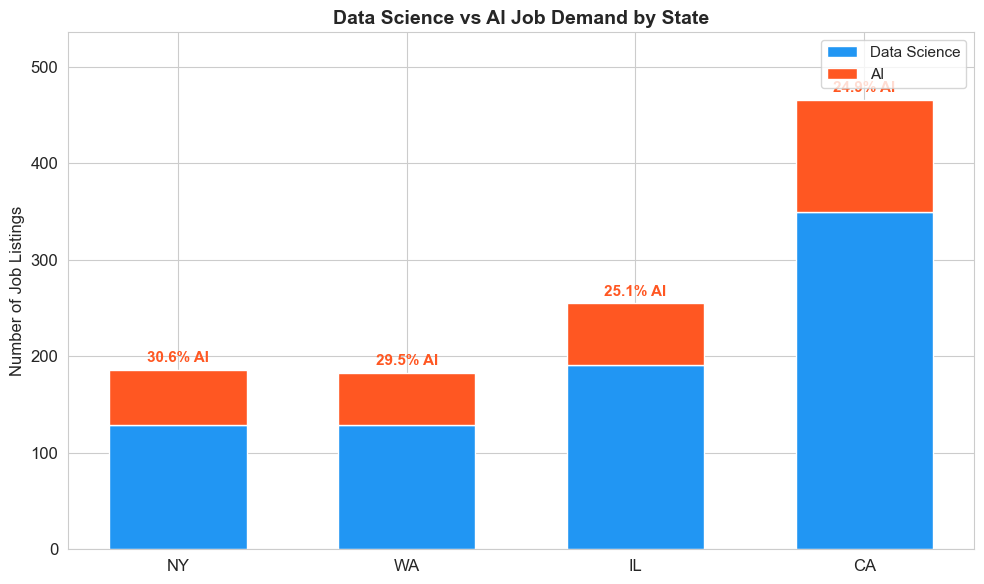

Saved: fig_q1_ds_vs_ai_by_state.png


In [5]:
# Visualization: Stacked bar chart (Lecture Part 2, Example 8 — stacked bars with crosstab)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Sort states by AI percentage (descending)
ct_pct_sorted = ct_pct.sort_values('AI', ascending=False)
ct_sorted = ct.reindex(ct_pct_sorted.index)

x = range(len(ct_sorted))
states_labels = ct_sorted.index.tolist()

# Stacked bars
bars_ds = ax1.bar(x, ct_sorted['Data Science'], label='Data Science',
                  color=DOMAIN_COLORS['Data Science'], edgecolor='white', width=0.6)
bars_ai = ax1.bar(x, ct_sorted['AI'], bottom=ct_sorted['Data Science'],
                  label='AI', color=DOMAIN_COLORS['AI'], edgecolor='white', width=0.6)

ax1.set_xticks(x)
ax1.set_xticklabels(states_labels, fontsize=12)
ax1.set_ylabel('Number of Job Listings', fontsize=12)
ax1.set_title('Data Science vs AI Job Demand by State', fontsize=14, fontweight='bold')

# Add AI percentage labels on bars
for i, state in enumerate(states_labels):
    total = ct_sorted.loc[state].sum()
    ai_pct = ct_pct_sorted.loc[state, 'AI']
    ax1.text(i, total + 8, f'{ai_pct:.1f}% AI', ha='center', fontsize=11, fontweight='bold',
             color=DOMAIN_COLORS['AI'])

ax1.legend(loc='upper right', fontsize=11)
ax1.set_ylim(0, ct_sorted.sum(axis=1).max() * 1.15)

plt.tight_layout()
plt.savefig('fig_q1_ds_vs_ai_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q1_ds_vs_ai_by_state.png")

In [6]:
# Statistical test: Chi-square — is the domain distribution independent of state?
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in domain distribution across states (α = 0.05)")

print(f"\n--- Key Findings ---")
ai_pcts = ct_pct_sorted['AI']
print(f"Highest AI share: {ai_pcts.idxmax()} ({ai_pcts.max():.1f}%)")
print(f"Lowest AI share: {ai_pcts.idxmin()} ({ai_pcts.min():.1f}%)")

Chi-square test: χ² = 3.33, p = 0.3436, df = 3
Result: Not significant difference in domain distribution across states (α = 0.05)

--- Key Findings ---
Highest AI share: NY (30.6%)
Lowest AI share: CA (24.9%)


---
## 4. Research Question 2: Experience Level Gap

**Question:** What percentage of AI roles are entry-level vs. senior, compared to DS roles? Are there barriers to entry in AI?

**Why it matters:** If AI roles skew heavily toward senior positions, it suggests that breaking into AI requires more experience — creating a workforce pipeline problem.

In [7]:
# Crosstab: domain x experience level
exp_order = ['Entry', 'Mid', 'Senior']
ct_exp = pd.crosstab(df['domain'], df['experience_level'])[exp_order]
ct_exp_pct = ct_exp.div(ct_exp.sum(axis=1), axis=0) * 100

print("Experience level counts:")
print(ct_exp)
print(f"\nPercentage breakdown:")
print(ct_exp_pct.round(1))

# Ratio analysis
for domain in ['AI', 'Data Science']:
    senior = ct_exp.loc[domain, 'Senior']
    entry = ct_exp.loc[domain, 'Entry']
    ratio = senior / entry if entry > 0 else float('inf')
    print(f"\n{domain}: {ratio:.1f} senior positions for every entry-level position")

Experience level counts:
experience_level  Entry  Mid  Senior
domain                              
AI                   28  376      70
Data Science         76  868     180

Percentage breakdown:
experience_level  Entry   Mid  Senior
domain                               
AI                  5.9  79.3    14.8
Data Science        6.8  77.2    16.0

AI: 2.5 senior positions for every entry-level position

Data Science: 2.4 senior positions for every entry-level position


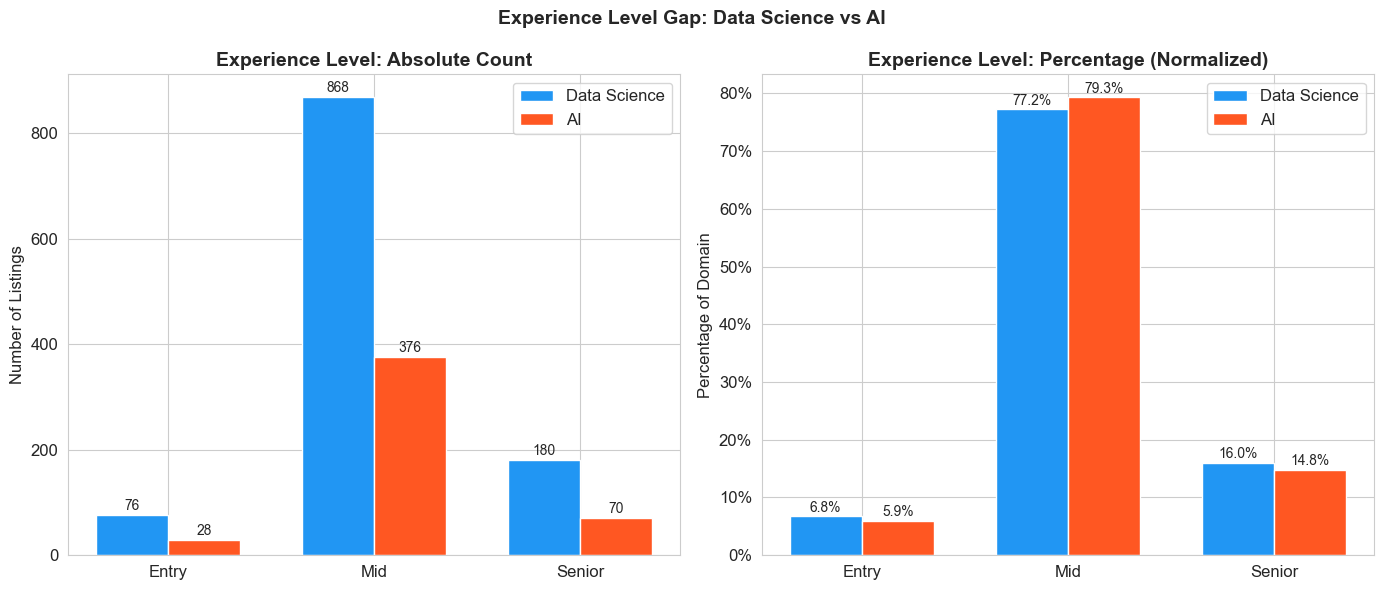

Saved: fig_q2_experience_gap.png


In [8]:
# Visualization: Grouped bar chart (Lecture Part 2 — bar chart with multiple groups)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Absolute counts
x = np.arange(len(exp_order))
width = 0.35

ax1.bar(x - width/2, ct_exp.loc['Data Science'], width, label='Data Science',
        color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax1.bar(x + width/2, ct_exp.loc['AI'], width, label='AI',
        color=DOMAIN_COLORS['AI'], edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(exp_order, fontsize=12)
ax1.set_ylabel('Number of Listings')
ax1.set_title('Experience Level: Absolute Count', fontweight='bold')
ax1.legend()

for i, level in enumerate(exp_order):
    ax1.text(i - width/2, ct_exp.loc['Data Science', level] + 10,
             str(ct_exp.loc['Data Science', level]), ha='center', fontsize=10)
    ax1.text(i + width/2, ct_exp.loc['AI', level] + 10,
             str(ct_exp.loc['AI', level]), ha='center', fontsize=10)

# Right: Percentage (normalized)
ax2.bar(x - width/2, ct_exp_pct.loc['Data Science'], width, label='Data Science',
        color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax2.bar(x + width/2, ct_exp_pct.loc['AI'], width, label='AI',
        color=DOMAIN_COLORS['AI'], edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(exp_order, fontsize=12)
ax2.set_ylabel('Percentage of Domain')
ax2.set_title('Experience Level: Percentage (Normalized)', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend()

for i, level in enumerate(exp_order):
    ax2.text(i - width/2, ct_exp_pct.loc['Data Science', level] + 0.8,
             f"{ct_exp_pct.loc['Data Science', level]:.1f}%", ha='center', fontsize=10)
    ax2.text(i + width/2, ct_exp_pct.loc['AI', level] + 0.8,
             f"{ct_exp_pct.loc['AI', level]:.1f}%", ha='center', fontsize=10)

fig.suptitle('Experience Level Gap: Data Science vs AI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q2_experience_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q2_experience_gap.png")

In [9]:
# Statistical test: Chi-square
chi2, p_value, dof, expected = stats.chi2_contingency(ct_exp)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in experience distribution between domains (α = 0.05)")

print(f"\n--- Entry-Level Breakdown by Category ---")
entry_by_cat = df[df['experience_level'] == 'Entry'].groupby('job_category').size().sort_values(ascending=False)
total_by_cat = df.groupby('job_category').size()
entry_pct = (entry_by_cat / total_by_cat * 100).sort_values(ascending=False)
for cat, pct in entry_pct.items():
    count = entry_by_cat.get(cat, 0)
    print(f"  {cat}: {count} entry-level ({pct:.1f}%)")

Chi-square test: χ² = 0.89, p = 0.6396, df = 2
Result: Not significant difference in experience distribution between domains (α = 0.05)

--- Entry-Level Breakdown by Category ---
  Data (General): 11 entry-level (22.0%)
  Analytics / Other: 4 entry-level (12.9%)
  Data Engineer: 4 entry-level (12.5%)
  Quantitative Analyst: 19 entry-level (11.8%)
  AI (General): 11 entry-level (10.5%)
  AI Engineer / Researcher: 7 entry-level (9.6%)
  Data Analyst: 23 entry-level (8.1%)
  Prompt Engineer: 3 entry-level (6.8%)
  Business Intelligence Analyst: 5 entry-level (5.3%)
  Data Scientist: 10 entry-level (4.6%)
  Machine Learning Engineer: 7 entry-level (2.8%)
  Business Analyst: 0 entry-level (nan%)


---
## 5. Research Question 3: Geographic Concentration

**Question:** Which metros dominate hiring for each role category? Is AI hiring more geographically concentrated than DS hiring?

**Why it matters:** Geographic concentration affects salary competition, talent availability, and relocation decisions for job seekers.

In [10]:
top_states = ['CA', 'IL', 'NY', 'WA']
df_geo = df[df['state'].isin(top_states)].copy()

# Crosstab: job category x state (percentage within each category)
ct_geo = pd.crosstab(df_geo['job_category'], df_geo['state'])
ct_geo_pct = ct_geo.div(ct_geo.sum(axis=1), axis=0) * 100
ct_geo_pct = ct_geo_pct.reindex(df_geo['job_category'].value_counts().index)

print("Geographic distribution (% of each category by state):")
print(ct_geo_pct.round(1))

Geographic distribution (% of each category by state):
state                            CA    IL    NY    WA
job_category                                         
Data Analyst                   48.1  20.4  14.1  17.5
Business Analyst               39.5  21.5  18.5  20.5
Machine Learning Engineer      38.8  20.8  20.8  19.7
Data Scientist                 53.9  18.0  14.4  13.8
Quantitative Analyst           31.4  36.2  25.7   6.7
Business Intelligence Analyst  53.2  38.7   1.6   6.5
AI (General)                   39.6  20.8  15.1  24.5
AI Engineer / Researcher       37.8  31.1  17.8  13.3
Data (General)                 37.5  21.9  12.5  28.1
Analytics / Other              17.6  17.6  35.3  29.4
Data Engineer                  20.0  33.3  13.3  33.3
Prompt Engineer                60.0  13.3  26.7   0.0


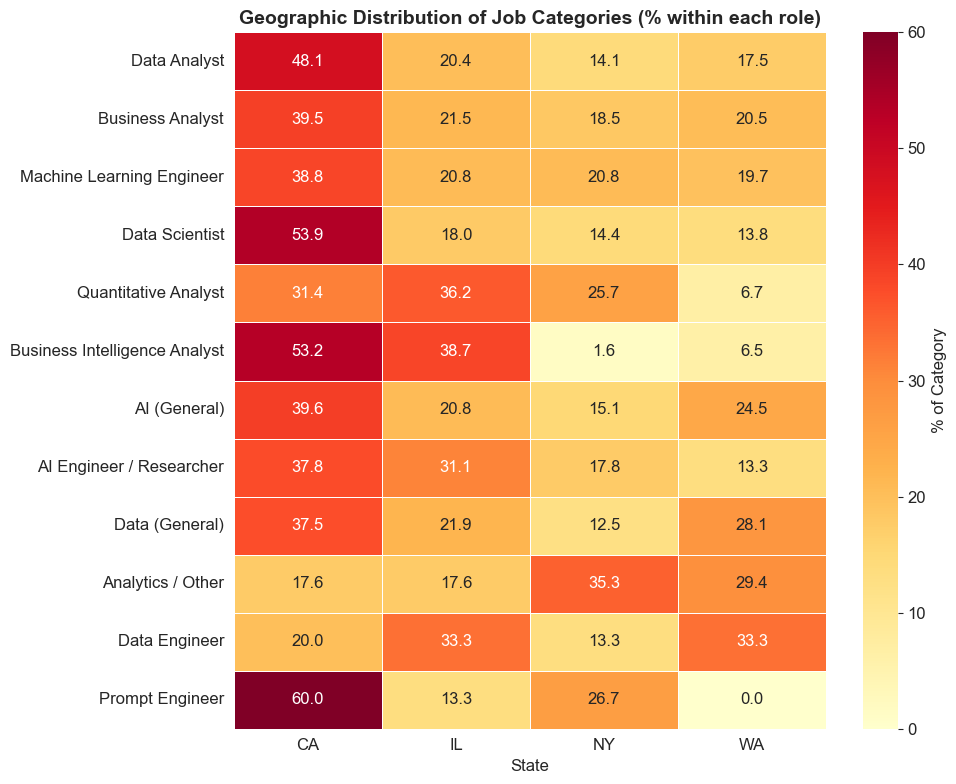

Saved: fig_q3_geographic_heatmap.png


In [11]:
# Visualization: Heatmap (Seaborn — Lecture Part 2)
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ct_geo_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Category'})

ax.set_title('Geographic Distribution of Job Categories (% within each role)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('fig_q3_geographic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q3_geographic_heatmap.png")

In [12]:
# Herfindahl-Hirschman Index (HHI) — higher = more concentrated

def calc_hhi(series):
    shares = series / series.sum()
    return (shares ** 2).sum()

hhi_by_domain = {}
for domain in ['AI', 'Data Science']:
    domain_geo = df_geo[df_geo['domain'] == domain]['state'].value_counts()
    hhi_by_domain[domain] = calc_hhi(domain_geo)

print("Geographic Concentration (HHI) by Domain:")
print(f"  (HHI ranges from 0 to 1; higher = more concentrated)")
for domain, hhi in hhi_by_domain.items():
    print(f"  {domain}: {hhi:.4f}")

more_concentrated = max(hhi_by_domain, key=hhi_by_domain.get)
print(f"\n→ {more_concentrated} hiring is more geographically concentrated")

print(f"\nHHI by Job Category (top 8):")
hhi_cats = {}
for cat in df_geo['job_category'].value_counts().head(8).index:
    cat_geo = df_geo[df_geo['job_category'] == cat]['state'].value_counts()
    hhi_cats[cat] = calc_hhi(cat_geo)

for cat, hhi in sorted(hhi_cats.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cat}: {hhi:.4f}")

Geographic Concentration (HHI) by Domain:
  (HHI ranges from 0 to 1; higher = more concentrated)
  AI: 0.2801
  Data Science: 0.3012

→ Data Science hiring is more geographically concentrated

HHI by Job Category (top 8):
  Business Intelligence Analyst: 0.4376
  Data Scientist: 0.3623
  Data Analyst: 0.3229
  Quantitative Analyst: 0.3003
  AI Engineer / Researcher: 0.2889
  AI (General): 0.2830
  Business Analyst: 0.2785
  Machine Learning Engineer: 0.2753


---
## 6. Research Question 4: Role Evolution

**Question:** How do emerging roles (Prompt Engineer, ML/AI Specialist) compare in volume and distribution to established ones (Data Analyst, Business Analyst)?

**Why it matters:** Understanding which roles are growing helps educational institutions design curricula and job seekers plan career paths.

In [13]:
established_roles = ['Data Analyst', 'Business Analyst', 'Data Scientist',
                     'Business Intelligence Analyst', 'Quantitative Analyst']
emerging_roles = ['Machine Learning Engineer', 'AI Engineer / Researcher',
                  'Prompt Engineer', 'AI (General)', 'Data Engineer']

def classify_era(cat):
    if cat in established_roles:
        return 'Established'
    elif cat in emerging_roles:
        return 'Emerging'
    return 'Other'

df['role_era'] = df['job_category'].apply(classify_era)

era_counts = df[df['role_era'] != 'Other'].groupby('role_era').size()
print("Established vs Emerging role counts:")
print(era_counts)
print(f"\nEstablished share: {era_counts['Established']/era_counts.sum():.1%}")
print(f"Emerging share: {era_counts['Emerging']/era_counts.sum():.1%}")

Established vs Emerging role counts:
role_era
Emerging        506
Established    1011
dtype: int64

Established share: 66.6%
Emerging share: 33.4%


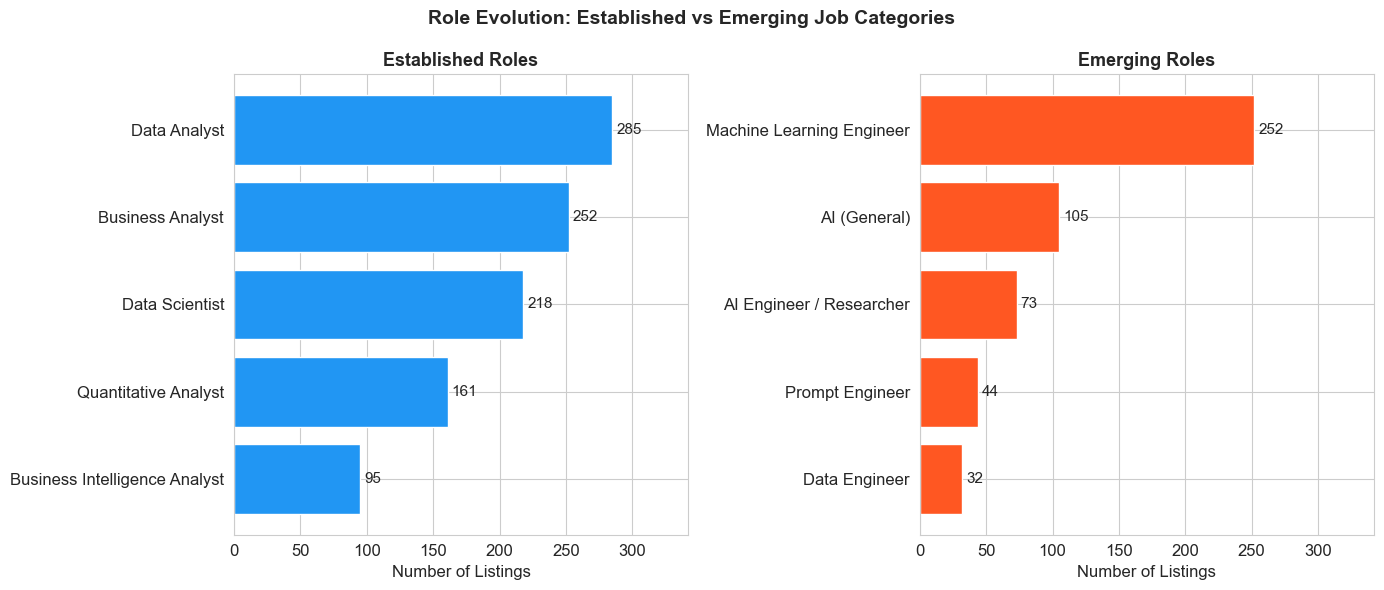

Saved: fig_q4_role_evolution.png


In [14]:
# Visualization: Side-by-side bar charts (Lecture Part 1 — subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Established roles
est_data = df[df['job_category'].isin(established_roles)]['job_category'].value_counts()
ax1.barh(est_data.index[::-1], est_data.values[::-1],
         color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax1.set_title('Established Roles', fontweight='bold', fontsize=13)
ax1.set_xlabel('Number of Listings')
for i, v in enumerate(est_data.values[::-1]):
    ax1.text(v + 3, i, str(v), va='center', fontsize=11)

# Right: Emerging roles
emg_data = df[df['job_category'].isin(emerging_roles)]['job_category'].value_counts()
ax2.barh(emg_data.index[::-1], emg_data.values[::-1],
         color=DOMAIN_COLORS['AI'], edgecolor='white')
ax2.set_title('Emerging Roles', fontweight='bold', fontsize=13)
ax2.set_xlabel('Number of Listings')
for i, v in enumerate(emg_data.values[::-1]):
    ax2.text(v + 3, i, str(v), va='center', fontsize=11)

max_val = max(est_data.max(), emg_data.max())
ax1.set_xlim(0, max_val * 1.2)
ax2.set_xlim(0, max_val * 1.2)

fig.suptitle('Role Evolution: Established vs Emerging Job Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q4_role_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q4_role_evolution.png")

In [15]:
# Deeper: experience level within established vs emerging
print("Experience level distribution by role era:")
era_exp = pd.crosstab(df[df['role_era'] != 'Other']['role_era'],
                      df[df['role_era'] != 'Other']['experience_level'])[exp_order]
era_exp_pct = era_exp.div(era_exp.sum(axis=1), axis=0) * 100
print(era_exp_pct.round(1))

print(f"\n--- Key Insight ---")
est_entry = era_exp_pct.loc['Established', 'Entry']
emg_entry = era_exp_pct.loc['Emerging', 'Entry']
print(f"Entry-level share: Established {est_entry:.1f}% vs Emerging {emg_entry:.1f}%")
if emg_entry < est_entry:
    print(f"→ Emerging roles have {est_entry - emg_entry:.1f}pp fewer entry-level positions")
    print(f"  This suggests higher barriers to entry for emerging AI/ML roles")

Experience level distribution by role era:
experience_level  Entry   Mid  Senior
role_era                             
Emerging            6.3  78.3    15.4
Established         5.6  78.3    16.0

--- Key Insight ---
Entry-level share: Established 5.6% vs Emerging 6.3%


---
## 7. Research Question 5: Job Title Complexity

**Question:** How does title length and seniority signaling differ across role categories and domains?

**Why it matters:** Title inflation and complexity can signal organizational maturity, role specialization, and hiring competitiveness.

In [16]:
print("Title length by domain:")
print(df.groupby('domain')['title_length'].describe()[['count', 'mean', 'std', 'min', 'max']].round(1))

# T-test: is title length significantly different between domains?
ai_lengths = df[df['domain'] == 'AI']['title_length']
ds_lengths = df[df['domain'] == 'Data Science']['title_length']
t_stat, p_value = stats.ttest_ind(ai_lengths, ds_lengths)
print(f"\nT-test (AI vs DS title length): t = {t_stat:.2f}, p = {p_value:.4f}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference (α = 0.05)")
print(f"AI mean: {ai_lengths.mean():.1f} chars vs DS mean: {ds_lengths.mean():.1f} chars")

Title length by domain:
               count  mean   std   min    max
domain                                       
AI             474.0  32.3  17.1  10.0  105.0
Data Science  1124.0  28.6  14.7  10.0  129.0

T-test (AI vs DS title length): t = 4.42, p = 0.0000
Result: Significant difference (α = 0.05)
AI mean: 32.3 chars vs DS mean: 28.6 chars


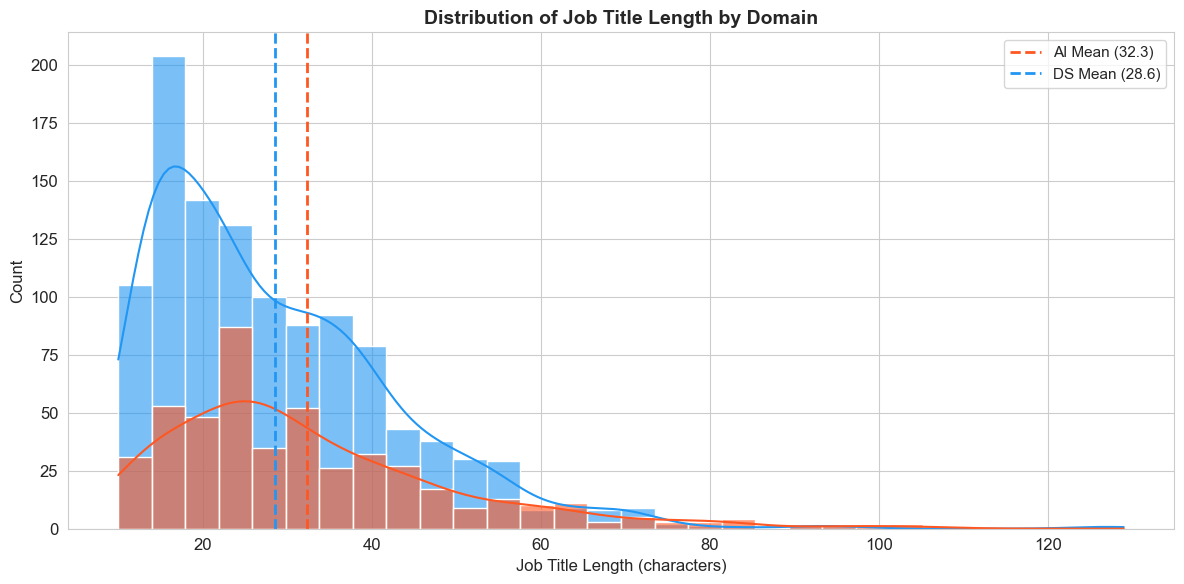

Saved: fig_q5_title_histogram.png


In [17]:
# Visualization: Histogram with KDE (Lecture Part 2, Example 4 + Seaborn histplot)
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(data=df, x='title_length', hue='domain', kde=True, bins=30,
             palette=DOMAIN_COLORS, alpha=0.6, ax=ax)

# Add vertical lines for means
ax.axvline(ai_lengths.mean(), color=DOMAIN_COLORS['AI'], linestyle='--', linewidth=2,
           label=f'AI Mean ({ai_lengths.mean():.1f})')
ax.axvline(ds_lengths.mean(), color=DOMAIN_COLORS['Data Science'], linestyle='--', linewidth=2,
           label=f'DS Mean ({ds_lengths.mean():.1f})')

ax.set_xlabel('Job Title Length (characters)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Job Title Length by Domain', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('fig_q5_title_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q5_title_histogram.png")

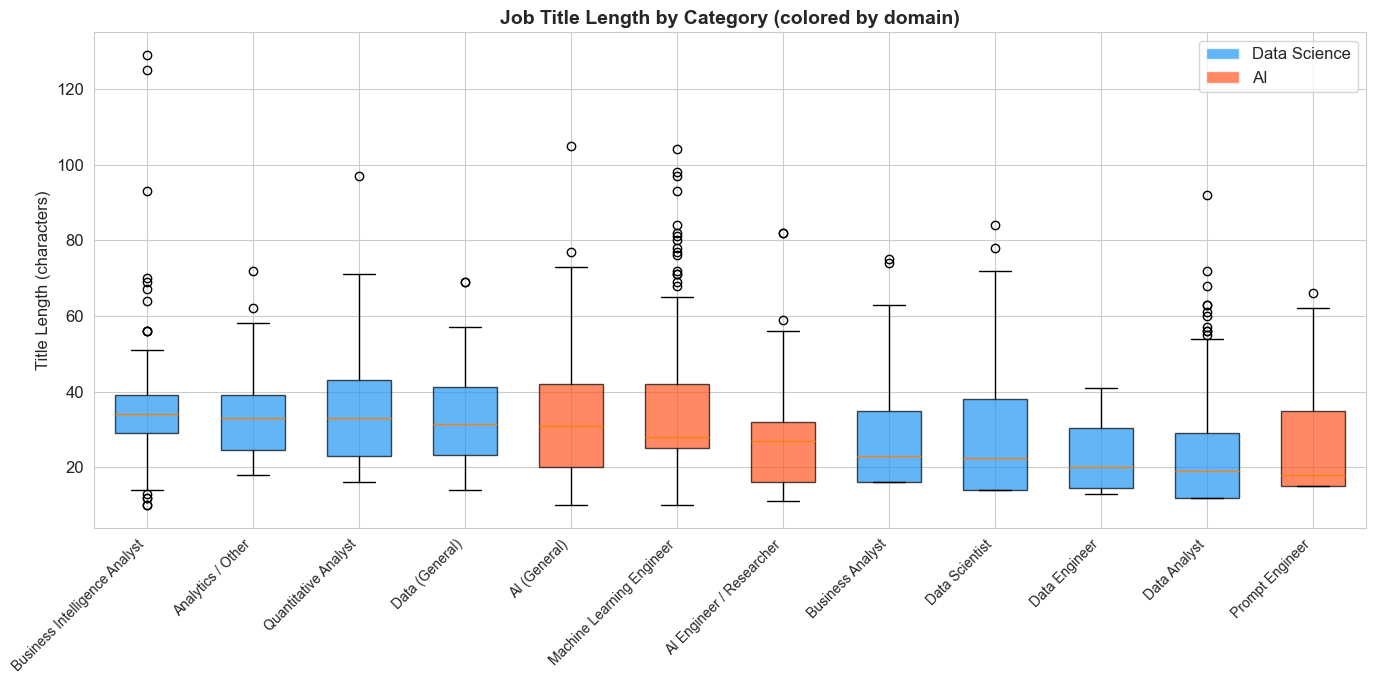

Saved: fig_q5_title_boxplot.png


In [18]:
# Visualization: Box plot by category (Lecture Part 1, Example 3)
fig, ax = plt.subplots(figsize=(14, 7))

cat_order = df.groupby('job_category')['title_length'].median().sort_values(ascending=False).index
cat_domain_map = df.groupby('job_category')['domain'].agg(lambda x: x.mode()[0])
box_colors = [DOMAIN_COLORS.get(cat_domain_map[cat], '#999') for cat in cat_order]

bp = ax.boxplot([df[df['job_category'] == cat]['title_length'].values for cat in cat_order],
                labels=cat_order, vert=True, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(cat_order, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Title Length (characters)')
ax.set_title('Job Title Length by Category (colored by domain)',
             fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=DOMAIN_COLORS['Data Science'], alpha=0.7, label='Data Science'),
                   Patch(facecolor=DOMAIN_COLORS['AI'], alpha=0.7, label='AI')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('fig_q5_title_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q5_title_boxplot.png")

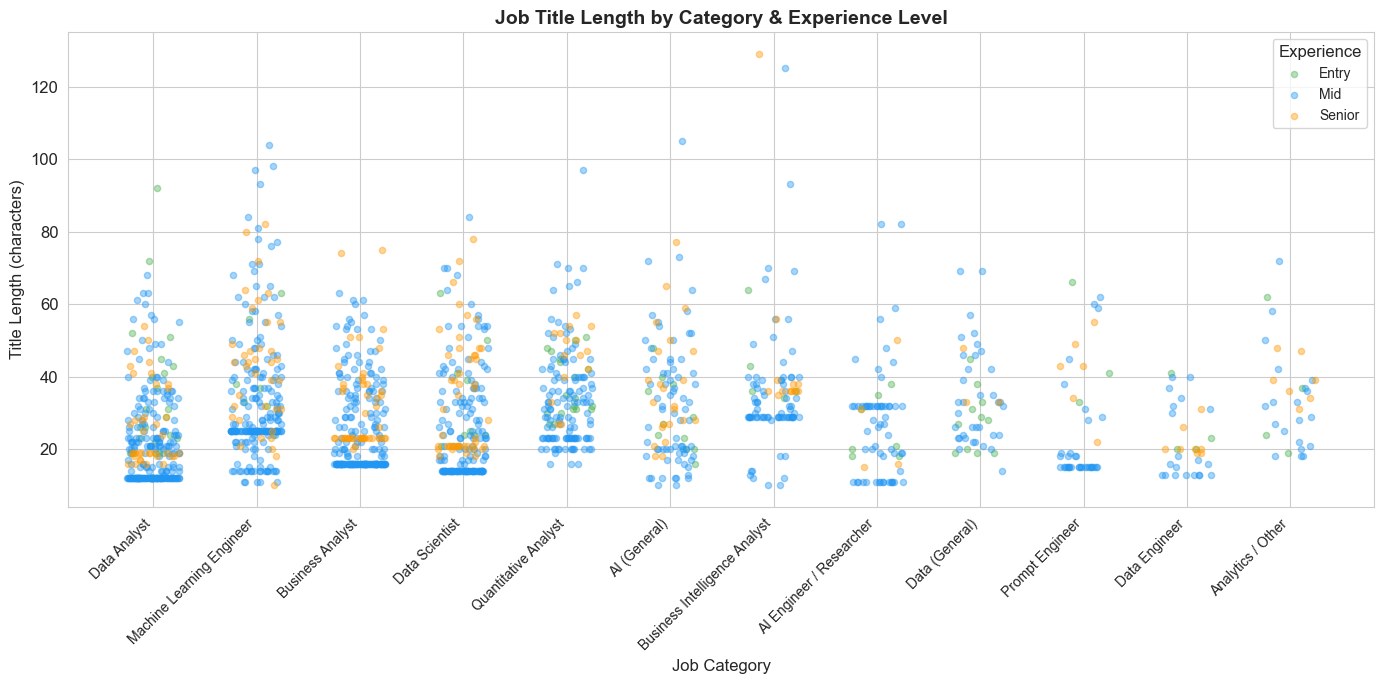

Saved: fig_q5_title_scatter.png


In [19]:
# Visualization: Scatter plot — title length by category, colored by experience level
# (Lecture Part 2, Example 6 — scatter with color/size encoding)

fig, ax = plt.subplots(figsize=(14, 7))

exp_colors = {'Entry': '#4CAF50', 'Mid': '#2196F3', 'Senior': '#FF9800'}

cat_order_list = df['job_category'].value_counts().index.tolist()
cat_to_num = {cat: i for i, cat in enumerate(cat_order_list)}

for level in ['Entry', 'Mid', 'Senior']:
    subset = df[df['experience_level'] == level]
    x_vals = subset['job_category'].map(cat_to_num)
    # Add jitter so points don't stack on top of each other
    x_jittered = x_vals + np.random.uniform(-0.25, 0.25, size=len(x_vals))
    ax.scatter(x_jittered, subset['title_length'], c=exp_colors[level],
               alpha=0.4, s=20, label=level)

ax.set_xticks(range(len(cat_order_list)))
ax.set_xticklabels(cat_order_list, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Title Length (characters)')
ax.set_xlabel('Job Category')
ax.set_title('Job Title Length by Category & Experience Level',
             fontsize=14, fontweight='bold')
ax.legend(title='Experience', fontsize=10)

plt.tight_layout()
plt.savefig('fig_q5_title_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q5_title_scatter.png")

In [20]:
# Seniority signaling + ANOVA
print("Seniority signaling by domain:")
for domain in ['AI', 'Data Science']:
    subset = df[df['domain'] == domain]
    senior_pct = subset['is_senior'].mean() * 100
    entry_pct = subset['is_entry'].mean() * 100
    print(f"  {domain}: {senior_pct:.1f}% senior-flagged, {entry_pct:.1f}% entry-flagged")

print(f"\nAverage title length by experience level:")
for level in ['Entry', 'Mid', 'Senior']:
    avg = df[df['experience_level'] == level]['title_length'].mean()
    print(f"  {level}: {avg:.1f} characters")

groups = [df[df['experience_level'] == level]['title_length'] for level in exp_order]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA (title length across experience levels): F = {f_stat:.2f}, p = {p_value:.4f}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference (α = 0.05)")

Seniority signaling by domain:
  AI: 14.8% senior-flagged, 6.3% entry-flagged
  Data Science: 16.0% senior-flagged, 6.9% entry-flagged

Average title length by experience level:
  Entry: 34.0 characters
  Mid: 28.2 characters
  Senior: 35.3 characters

ANOVA (title length across experience levels): F = 26.73, p = 0.0000
Result: Significant difference (α = 0.05)


---
## 8. Interactive Visualizations with Plotly

Following the Plotly examples from Lecture Part 2, we create interactive charts with hover tools and dropdown menus.

In [21]:
import sys
!{sys.executable} -m pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\D3E2J\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
import plotly.express as px

# Interactive scatter: bubble chart of job category x state, sized by count
plot_data = (df[df['state'].isin(['CA', 'IL', 'NY', 'WA'])]
             .groupby(['state', 'job_category', 'domain'])
             .size()
             .reset_index(name='count'))

fig = px.scatter(plot_data, x='state', y='job_category', size='count',
                 color='domain', hover_data=['count'],
                 color_discrete_map=DOMAIN_COLORS,
                 title='Job Listings by State & Category (hover for details)',
                 labels={'state': 'State', 'job_category': 'Job Category',
                         'count': 'Listings', 'domain': 'Domain'})

fig.update_layout(height=600, width=900)
fig.show()

In [23]:
import plotly.graph_objects as go

# Prepare data for each domain
ds_cats = df[df['domain'] == 'Data Science']['job_category'].value_counts()
ai_cats = df[df['domain'] == 'AI']['job_category'].value_counts()

fig = go.Figure()

fig.add_trace(go.Bar(x=ds_cats.index, y=ds_cats.values, name='Data Science',
                     marker_color=DOMAIN_COLORS['Data Science'], visible=True))
fig.add_trace(go.Bar(x=ai_cats.index, y=ai_cats.values, name='AI',
                     marker_color=DOMAIN_COLORS['AI'], visible=True))

# Dropdown menu to toggle domain views
fig.update_layout(
    title='Job Categories by Domain (use dropdown to filter)',
    xaxis_title='Job Category',
    yaxis_title='Number of Listings',
    xaxis_tickangle=-45,
    height=500,
    updatemenus=[
        dict(
            buttons=list([
                dict(args=[{'visible': [True, True]}],
                     label='Both Domains', method='update'),
                dict(args=[{'visible': [True, False]}],
                     label='Data Science Only', method='update'),
                dict(args=[{'visible': [False, True]}],
                     label='AI Only', method='update'),
            ]),
            direction='down',
            showactive=True,
            x=0.85,
            y=1.15,
        )
    ]
)

fig.show()

In [24]:
fig = px.histogram(df, x='title_length', color='domain',
                   color_discrete_map=DOMAIN_COLORS,
                   nbins=40, barmode='overlay', opacity=0.6,
                   title='Title Length Distribution by Domain (Interactive)',
                   labels={'title_length': 'Title Length (characters)',
                           'domain': 'Domain', 'count': 'Listings'})

fig.update_layout(height=450, width=800)
fig.show()

---
## 9. Summary of Findings

In [25]:
print("=" * 70)
print("SUMMARY OF KEY FINDINGS")
print("=" * 70)

print(f"""
Dataset: {len(df)} job listings from {df['source'].nunique()} sources
         {df[df['domain']=='Data Science'].shape[0]} Data Science | {df[df['domain']=='AI'].shape[0]} AI

Q1 — DS vs AI Demand by City:
  • AI roles represent {df[df['domain']=='AI'].shape[0]/len(df):.1%} of all listings
  • AI concentration varies by state (see chi-square results above)
  • California leads in absolute AI job count

Q2 — Experience Level Gap:
  • Entry-level: {df[(df['domain']=='AI') & (df['experience_level']=='Entry')].shape[0]/df[df['domain']=='AI'].shape[0]:.1%} of AI vs {df[(df['domain']=='Data Science') & (df['experience_level']=='Entry')].shape[0]/df[df['domain']=='Data Science'].shape[0]:.1%} of DS roles
  • AI has a higher senior-to-entry ratio, suggesting steeper barriers to entry

Q3 — Geographic Concentration:
  • Top 4 states (CA, IL, NY, WA) account for {len(df[df['state'].isin(['CA','IL','NY','WA'])])/len(df):.1%} of listings with known locations
  • California dominates across most categories

Q4 — Role Evolution:
  • Established roles: {len(df[df['role_era']=='Established'])} listings
  • Emerging roles: {len(df[df['role_era']=='Emerging'])} listings
  • ML Engineer is the largest emerging category ({len(df[df['job_category']=='Machine Learning Engineer'])} listings)
  • Prompt Engineer is still niche ({len(df[df['job_category']=='Prompt Engineer'])} listings)

Q5 — Title Complexity:
  • AI roles have longer titles on average ({ai_lengths.mean():.1f} vs {ds_lengths.mean():.1f} chars)
  • Senior roles have longer titles than entry-level roles

Visualization types used:
  • Pie chart, bar chart (vertical & horizontal), stacked bar chart
  • Histogram with KDE, box plot, scatter plot
  • Seaborn heatmap
  • Plotly interactive scatter, bar chart with dropdown, histogram
""")

print("=" * 70)

SUMMARY OF KEY FINDINGS

Dataset: 1598 job listings from 2 sources
         1124 Data Science | 474 AI

Q1 — DS vs AI Demand by City:
  • AI roles represent 29.7% of all listings
  • AI concentration varies by state (see chi-square results above)
  • California leads in absolute AI job count

Q2 — Experience Level Gap:
  • Entry-level: 5.9% of AI vs 6.8% of DS roles
  • AI has a higher senior-to-entry ratio, suggesting steeper barriers to entry

Q3 — Geographic Concentration:
  • Top 4 states (CA, IL, NY, WA) account for 68.2% of listings with known locations
  • California dominates across most categories

Q4 — Role Evolution:
  • Established roles: 1011 listings
  • Emerging roles: 506 listings
  • ML Engineer is the largest emerging category (252 listings)
  • Prompt Engineer is still niche (44 listings)

Q5 — Title Complexity:
  • AI roles have longer titles on average (32.3 vs 28.6 chars)
  • Senior roles have longer titles than entry-level roles

Visualization types used:
  • Pie

---
## 10. Managerial Recommendations

Based on our analysis, we offer the following recommendations:

### For Job Seekers:
1. **Entry-level AI candidates** should consider building Data Science experience first, as entry-level AI positions are scarce. Transitioning from Data Analyst → Data Scientist → ML Engineer is a viable pathway.
2. **Geographic flexibility matters.** California dominates AI hiring, but other metros (Chicago, New York, Seattle) offer strong DS/analytics markets with potentially less competition.
3. **Data Analyst remains the highest-volume entry point** into the field, with the most listings and the strongest entry-level presence.

### For Employers & Hiring Managers:
1. **The entry-level AI pipeline is thin.** Organizations relying on AI talent should invest in internal training programs and junior development roles to build their pipeline.
2. **Title standardization matters.** AI roles show more title variation and complexity, which may hinder job discovery and candidate matching.
3. **Geographic concentration creates risk.** Over-reliance on a single metro for AI talent creates competition and cost pressure. Consider emerging tech hubs.

### For Educational Institutions:
1. **Curricula should bridge DS and AI.** The data shows a clear demand gradient — students need DS fundamentals before specializing in ML/AI.
2. **Prompt Engineering is emerging but small.** It may be premature to build full programs around it, but incorporating it into existing AI coursework is prudent.

---

### Data Limitations
- **Salary data** was sparse (primarily from RemoteOK) and insufficient for statistical analysis. Future work could supplement with Glassdoor or BLS data.
- **Remote work classification** was limited by LinkedIn's public search pages not exposing remote/hybrid metadata. Actual remote availability is likely higher than our data reflects.
- **Temporal analysis** was not possible as LinkedIn public listings lack consistent posting dates.
- **Scraping window** reflects a single point in time and may not capture seasonal hiring patterns.

In [26]:
# List all saved figures for the presentation
import os
figures = [f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')]
print(f"\nFigures saved for presentation ({len(figures)}):")
for f in sorted(figures):
    print(f"  → {f}")


Figures saved for presentation (8):
  → fig_overview.png
  → fig_q1_ds_vs_ai_by_state.png
  → fig_q2_experience_gap.png
  → fig_q3_geographic_heatmap.png
  → fig_q4_role_evolution.png
  → fig_q5_title_boxplot.png
  → fig_q5_title_histogram.png
  → fig_q5_title_scatter.png
